<a href="https://colab.research.google.com/github/luccasnn/previsao-imoveis/blob/main/previsao_imoveis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dataset real de imóveis - California Housing
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Preco'] = housing.target

print("Shape:", df.shape)
print("\nColunas:", df.columns.tolist())
print("\nValores nulos:")
print(df.isnull().sum())
df.head()

Shape: (20640, 9)

Colunas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Preco']

Valores nulos:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Preco         0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Preco
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


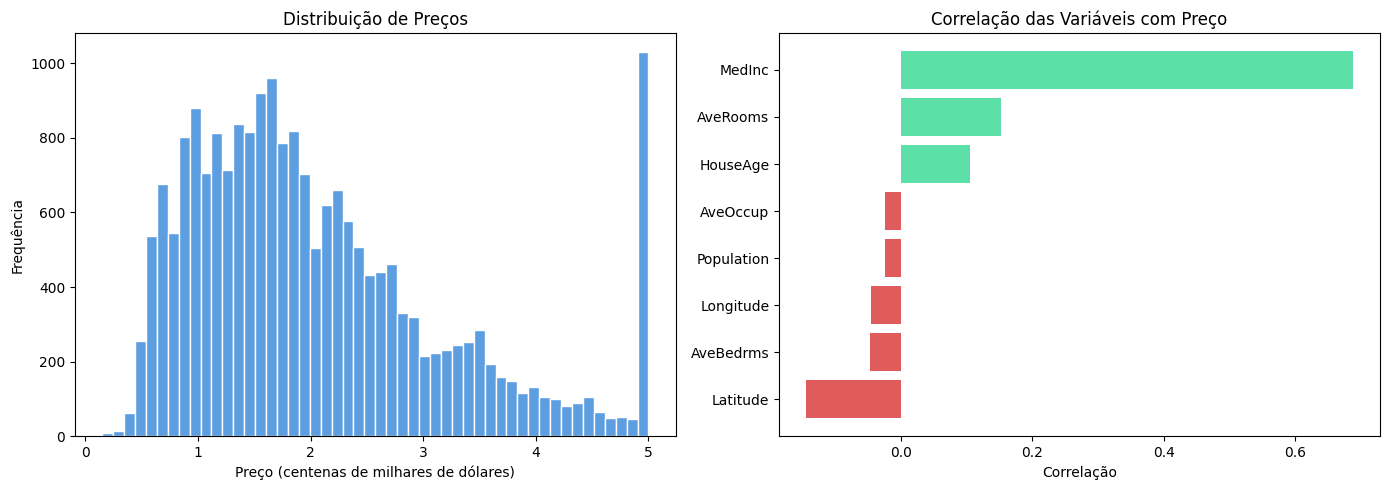


Variável mais correlacionada com preço:
MedInc -> 0.688


In [4]:
# Exploração inicial
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição do preço
axes[0].hist(df['Preco'], bins=50, color='#5c9ee0', edgecolor='white')
axes[0].set_title('Distribuição de Preços')
axes[0].set_xlabel('Preço (centenas de milhares de dólares)')
axes[0].set_ylabel('Frequência')

# Correlação com o preço
correlacoes = df.corr()['Preco'].drop('Preco').sort_values()
axes[1].barh(correlacoes.index, correlacoes.values,
             color=['#e05c5c' if v < 0 else '#5ce0a8' for v in correlacoes.values])
axes[1].set_title('Correlação das Variáveis com Preço')
axes[1].set_xlabel('Correlação')

plt.tight_layout()
plt.savefig('exploracao_imoveis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVariável mais correlacionada com preço:")
print(correlacoes.abs().idxmax(), "->", round(correlacoes.abs().max(), 3))

In [6]:
# Separação features e target
X = df.drop('Preco', axis=1)
y = df['Preco']

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste: {X_test.shape[0]} registros")

# Modelo 1 - Regressão Linear
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Modelo 2 - Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Métricas
print("\n=== REGRESSÃO LINEAR ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lr):.3f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_lr)**0.5:.3f}")
print(f"R²:   {r2_score(y_test, y_pred_lr):.3f}")

print("\n=== RANDOM FOREST ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_rf)**0.5:.3f}")
print(f"R²:   {r2_score(y_test, y_pred_rf):.3f}")

Treino: 16512 registros
Teste: 4128 registros

=== REGRESSÃO LINEAR ===
MAE:  0.533
RMSE: 0.746
R²:   0.576

=== RANDOM FOREST ===
MAE:  0.328
RMSE: 0.505
R²:   0.805


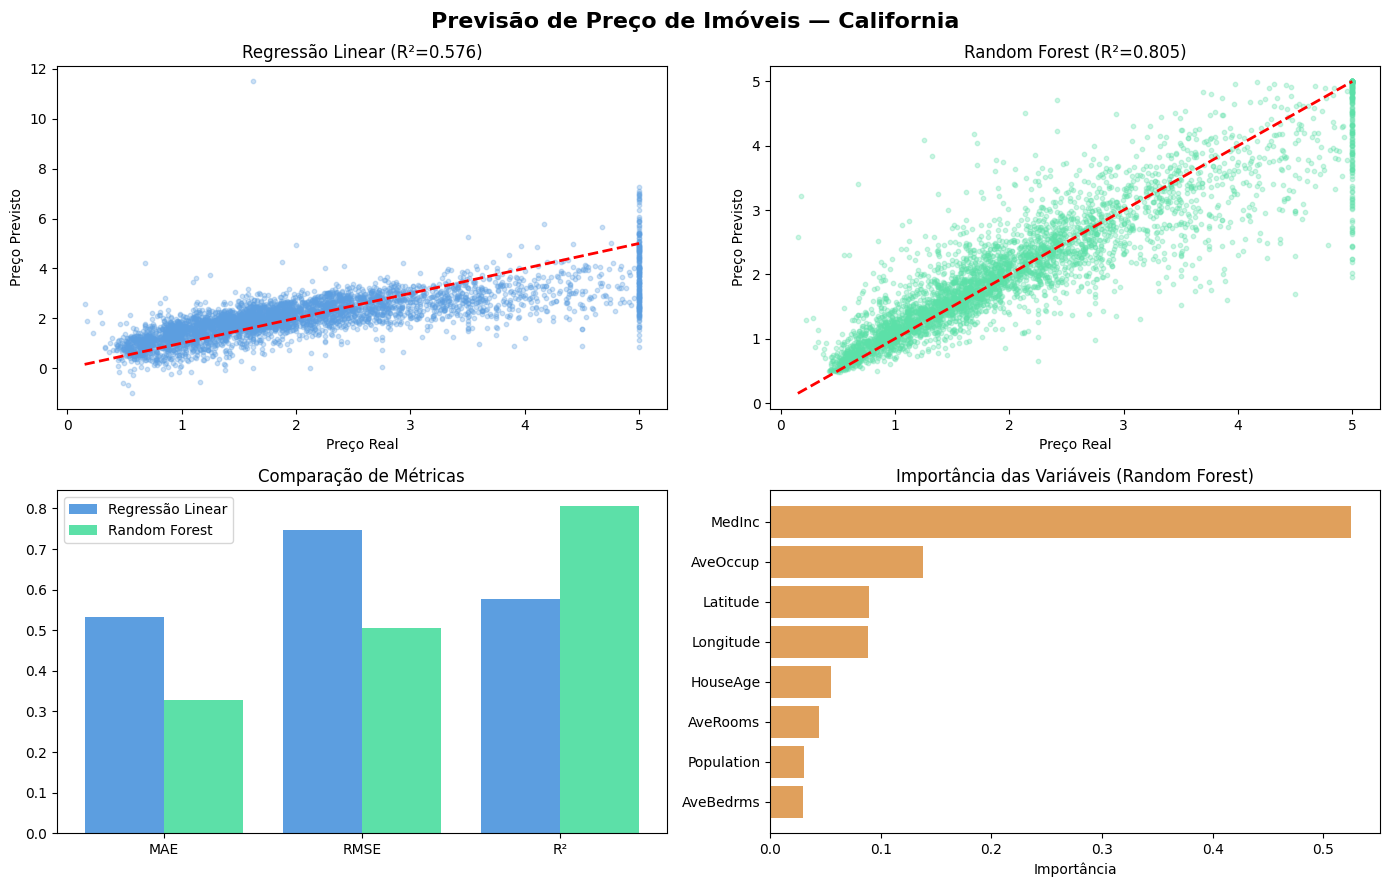

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Previsão de Preço de Imóveis — California', fontsize=16, fontweight='bold')

# 1. Real vs Previsto - Regressão Linear
axes[0, 0].scatter(y_test, y_pred_lr, alpha=0.3, color='#5c9ee0', s=10)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', linewidth=2)
axes[0, 0].set_title(f'Regressão Linear (R²=0.576)')
axes[0, 0].set_xlabel('Preço Real')
axes[0, 0].set_ylabel('Preço Previsto')

# 2. Real vs Previsto - Random Forest
axes[0, 1].scatter(y_test, y_pred_rf, alpha=0.3, color='#5ce0a8', s=10)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', linewidth=2)
axes[0, 1].set_title(f'Random Forest (R²=0.805)')
axes[0, 1].set_xlabel('Preço Real')
axes[0, 1].set_ylabel('Preço Previsto')

# 3. Comparação de métricas
metricas = ['MAE', 'RMSE', 'R²']
lr_vals = [0.533, 0.746, 0.576]
rf_vals = [0.328, 0.505, 0.805]
x = range(len(metricas))
axes[1, 0].bar([i - 0.2 for i in x], lr_vals, width=0.4, label='Regressão Linear', color='#5c9ee0')
axes[1, 0].bar([i + 0.2 for i in x], rf_vals, width=0.4, label='Random Forest', color='#5ce0a8')
axes[1, 0].set_xticks(list(x))
axes[1, 0].set_xticklabels(metricas)
axes[1, 0].set_title('Comparação de Métricas')
axes[1, 0].legend()

# 4. Feature importance - Random Forest
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
axes[1, 1].barh(importancias.index, importancias.values, color='#e0a05c')
axes[1, 1].set_title('Importância das Variáveis (Random Forest)')
axes[1, 1].set_xlabel('Importância')

plt.tight_layout()
plt.savefig('previsao_imoveis.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
from google.colab import files

files.download('previsao_imoveis.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>